In [3]:
import os, copy
import glob

import numpy as np
import pandas as pd
import xarray as xr
#%matplotlib widget
import matplotlib as mpl
import matplotlib.pyplot as plt
import colorcet as cc
import hgrs

In [4]:
sza=40
vza=10
raa=90
wl=np.linspace(400,2500,1000)
wl_glint=2200
brdfg_ref=0.1

In [5]:
lut_file = '/DATA/git/satellite_app/hgrs/data/lut/opac_osoaa_lut_v3.nc'
aero_lut = xr.open_dataset(lut_file)
aero_lut['wl']=aero_lut['wl']*1000

lut_file_bot = '/DATA/git/satellite_app/hgrs/data/lut/opac_osoaa_water_bottom_albedo_1_lut.nc'
aero_lut_bot = xr.open_dataset(lut_file_bot)
aero_lut_bot['wl']=aero_lut_bot['wl']*1000

aero_lut=aero_lut.isel(z=-1).squeeze()

In [6]:
M = 1/np.cos(np.radians(sza)) + 1/np.cos(np.radians(vza))
azi=180-raa
def transmittance_dir(aot,M,rot=0):    
    return np.exp(-(rot+aot)*M)


auxdata = hgrs.auxdata()#wl=masked.wl)

sunglint_eps = auxdata.sunglint_eps['mean'].interp(wl=wl)
sunglint_corr = sunglint_eps / sunglint_eps.sel(wl=wl_glint,method='nearest')
rot = auxdata.rot.interp(wl=wl)


In [7]:
aero_lut_bot

<xarray.Dataset>
Dimensions:            (wl: 10, model: 8, aot_ref: 9, z: 2, sza: 9, vza: 61,
                        azi: 73)
Coordinates:
  * wl                 (wl) float32 350.0 400.0 500.0 ... 2.2e+03 2.5e+03
  * aot_ref            (aot_ref) float32 0.001 0.01 0.1 0.2 0.35 0.5 0.7 1.0 1.5
  * z                  (z) float32 0.0 3e+05
  * sza                (sza) float32 0.0 10.0 20.0 30.0 40.0 50.0 60.0 70.0 80.0
  * vza                (vza) float32 0.0 1.14 2.62 4.11 ... 86.27 87.76 89.25
  * azi                (azi) float32 0.0 5.0 10.0 15.0 ... 350.0 355.0 360.0
  * model              (model) object 'COAV_rh70' 'DESE_rh70' ... 'ANTA_rh70'
Data variables: (12/20)
    wl_ref             (model, wl, aot_ref) float32 ...
    Cext_ref           (model, wl, aot_ref) float32 ...
    ssa_ref            (model, wl, aot_ref) float32 ...
    aot                (model, wl, aot_ref) float32 ...
    Cext               (model, wl, aot_ref) float32 ...
    ssa                (model, wl, aot_ref) float32 ...
    ...                 ...
    Eddir              (model, aot_ref, wl, z, sza) float32 ...
    Eudir              (model, aot_ref, wl, z, sza) float32 ...
    Eodir              (model, aot_ref, wl, z, sza) float32 ...
    I                  (model, wl, aot_ref, z, sza, vza, azi) float32 ...
    Q                  (model, wl, aot_ref, z, sza, vza, azi) float32 ...
    U                  (model, wl, aot_ref, z, sza, vza, azi) float32 ...

In [8]:
aero_lut

<xarray.Dataset>
Dimensions:            (wl: 10, model: 32, aot_ref: 9, sza: 9, vza: 61, azi: 73)
Coordinates:
  * wl                 (wl) float32 350.0 400.0 500.0 ... 2.2e+03 2.5e+03
  * aot_ref            (aot_ref) float32 0.001 0.01 0.1 0.2 0.35 0.5 0.7 1.0 1.5
    z                  float32 3e+05
  * sza                (sza) float32 0.0 10.0 20.0 30.0 40.0 50.0 60.0 70.0 80.0
  * vza                (vza) float32 0.0 1.14 2.62 4.11 ... 86.27 87.76 89.25
  * azi                (azi) float32 0.0 5.0 10.0 15.0 ... 350.0 355.0 360.0
  * model              (model) object 'COAV_rh0' 'DESE_rh0' ... 'ANTA_rh99'
Data variables: (12/20)
    wl_ref             (model, wl, aot_ref) float32 ...
    Cext_ref           (model, wl, aot_ref) float32 ...
    ssa_ref            (model, wl, aot_ref) float32 ...
    aot                (model, wl, aot_ref) float32 ...
    Cext               (model, wl, aot_ref) float32 ...
    ssa                (model, wl, aot_ref) float32 ...
    ...                 ...
    Eddir              (model, aot_ref, wl, sza) float32 ...
    Eudir              (model, aot_ref, wl, sza) float32 ...
    Eodir              (model, aot_ref, wl, sza) float32 ...
    I                  (model, wl, aot_ref, sza, vza, azi) float32 ...
    Q                  (model, wl, aot_ref, sza, vza, azi) float32 ...
    U                  (model, wl, aot_ref, sza, vza, azi) float32 ...

In [15]:
cmap = mpl.colors.LinearSegmentedColormap.from_list("",
                                                    ['navy', "blue", 'lightskyblue',
                                                     "grey",   'forestgreen','yellowgreen',
                                                     "khaki", "gold",
                                                     'orangered', "firebrick", 'purple'])

norm = mpl.colors.Normalize(vmin=0.001,vmax=1.1)#-3, vmax=np.log10(1.5))

models = ['ANTA','ARCT','COAV', 'COPO', 'DESE', 'MACL']#, 'MAPO', 'URBA']
rh='_rh70'

## Plot sunglint signal

In [21]:
brdfg_ref=0.1

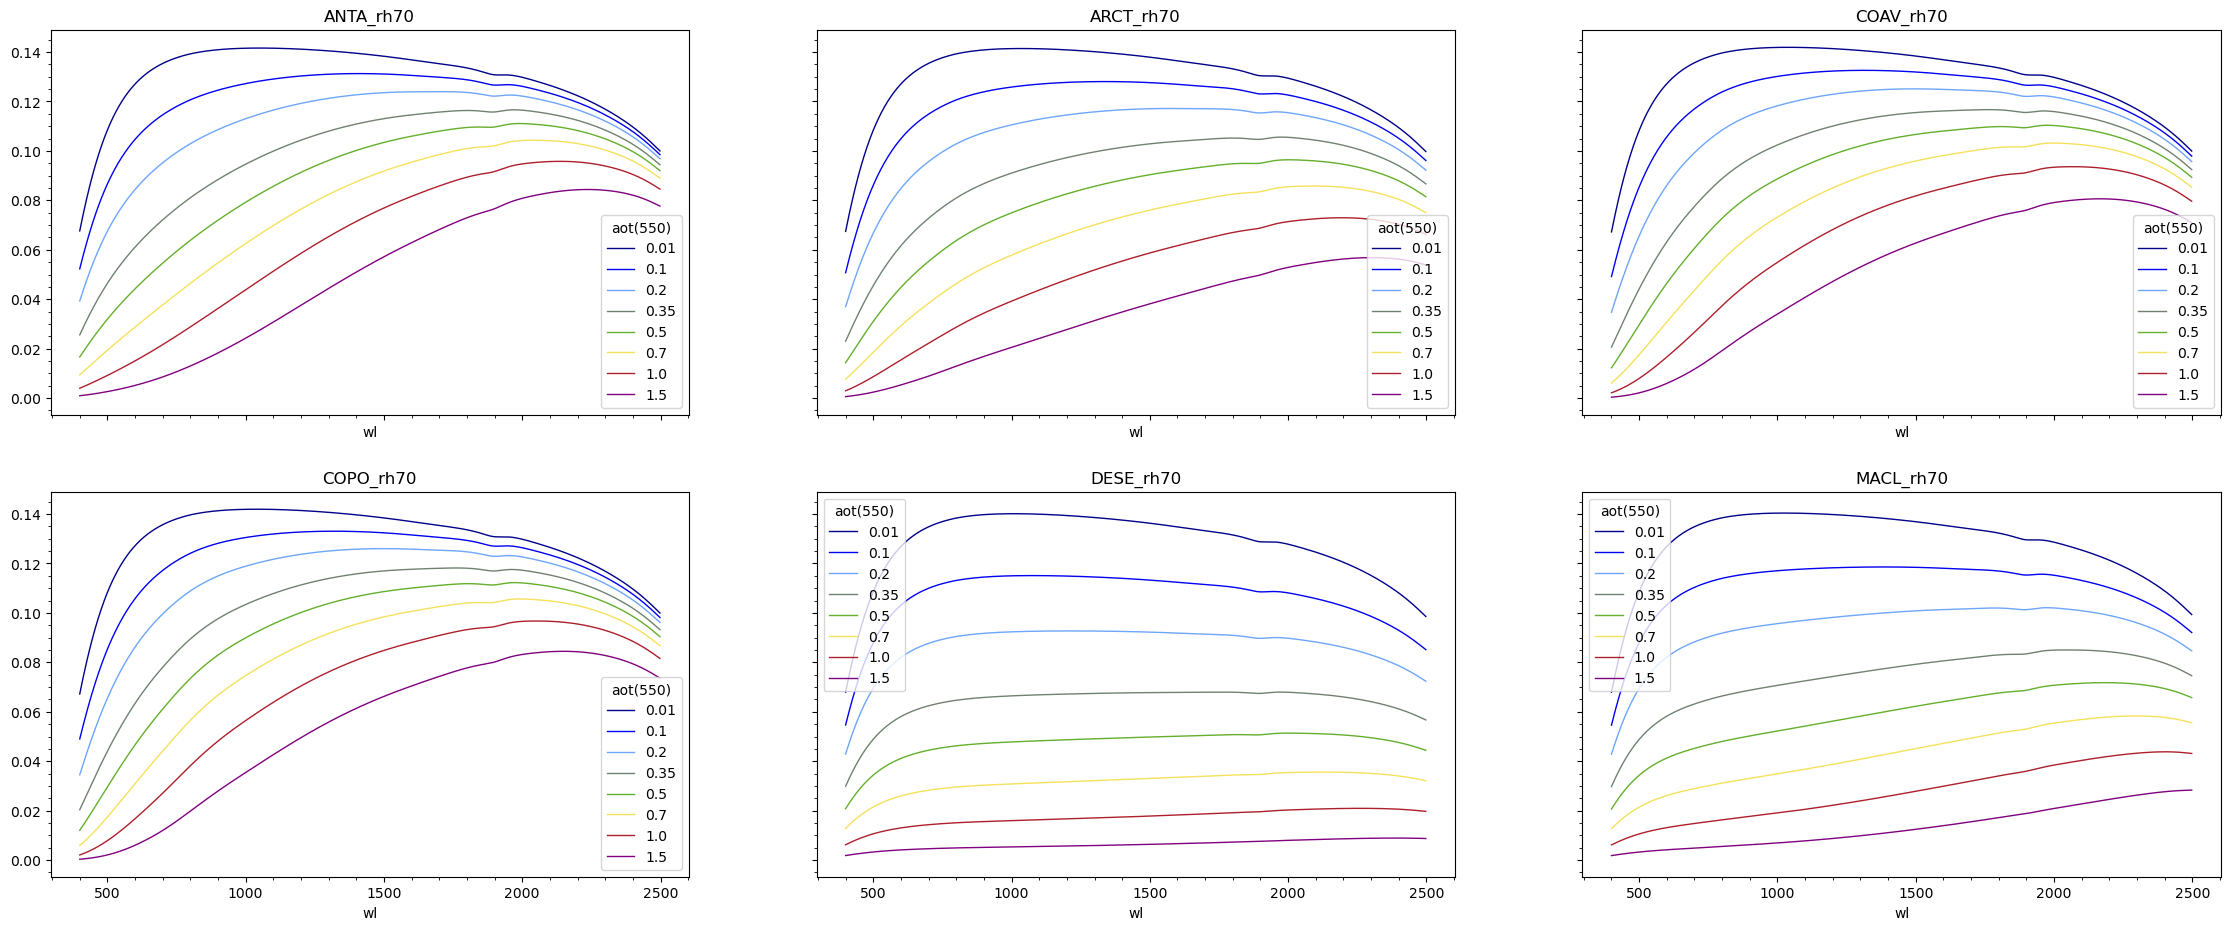

In [22]:
fig,axs = plt.subplots(2,3,figsize=(28,11),sharey=True,sharex=True)
axs=axs.ravel()
for i_,model_ in  enumerate(models):
    model=model_+rh
      
    aot=aero_lut.sel(model=model).aot.interp(wl=wl,method='cubic')
    Tdir = transmittance_dir(aot,M,rot=rot)
    sunglint_corr = Tdir * sunglint_eps
    sunglint_toa=sunglint_corr *brdfg_ref#( pixel.sel(wl=slice(2150,2350))-Rtoa_lut.sel(wl=slice(2150,2350))).mean(dim='wl')
    #sunglint_toa.Rtoa.plot(x='wl',hue='aot_ref',ax=axs[0])
    
    Rsim = ( sunglint_toa)#Rtoa_lut+
    for aot_ref in aot.aot_ref.values[1:]:
       
        Rsim.sel(aot_ref=aot_ref).plot(x='wl',color=cmap(norm(aot_ref)),label=str(aot_ref),lw=1,ax=axs[i_])
    #Rtoa_sim= Rsim.interp(aot_ref=0.4)
    #Rtoa_sim.plot(x='wl',color='black',ls='--',ax=axs[i_])
    axs[i_].set_title(model)
    axs[i_].minorticks_on()
    axs[i_].legend(title='aot(550)')

## Plot sunglint signal plus diffuse light

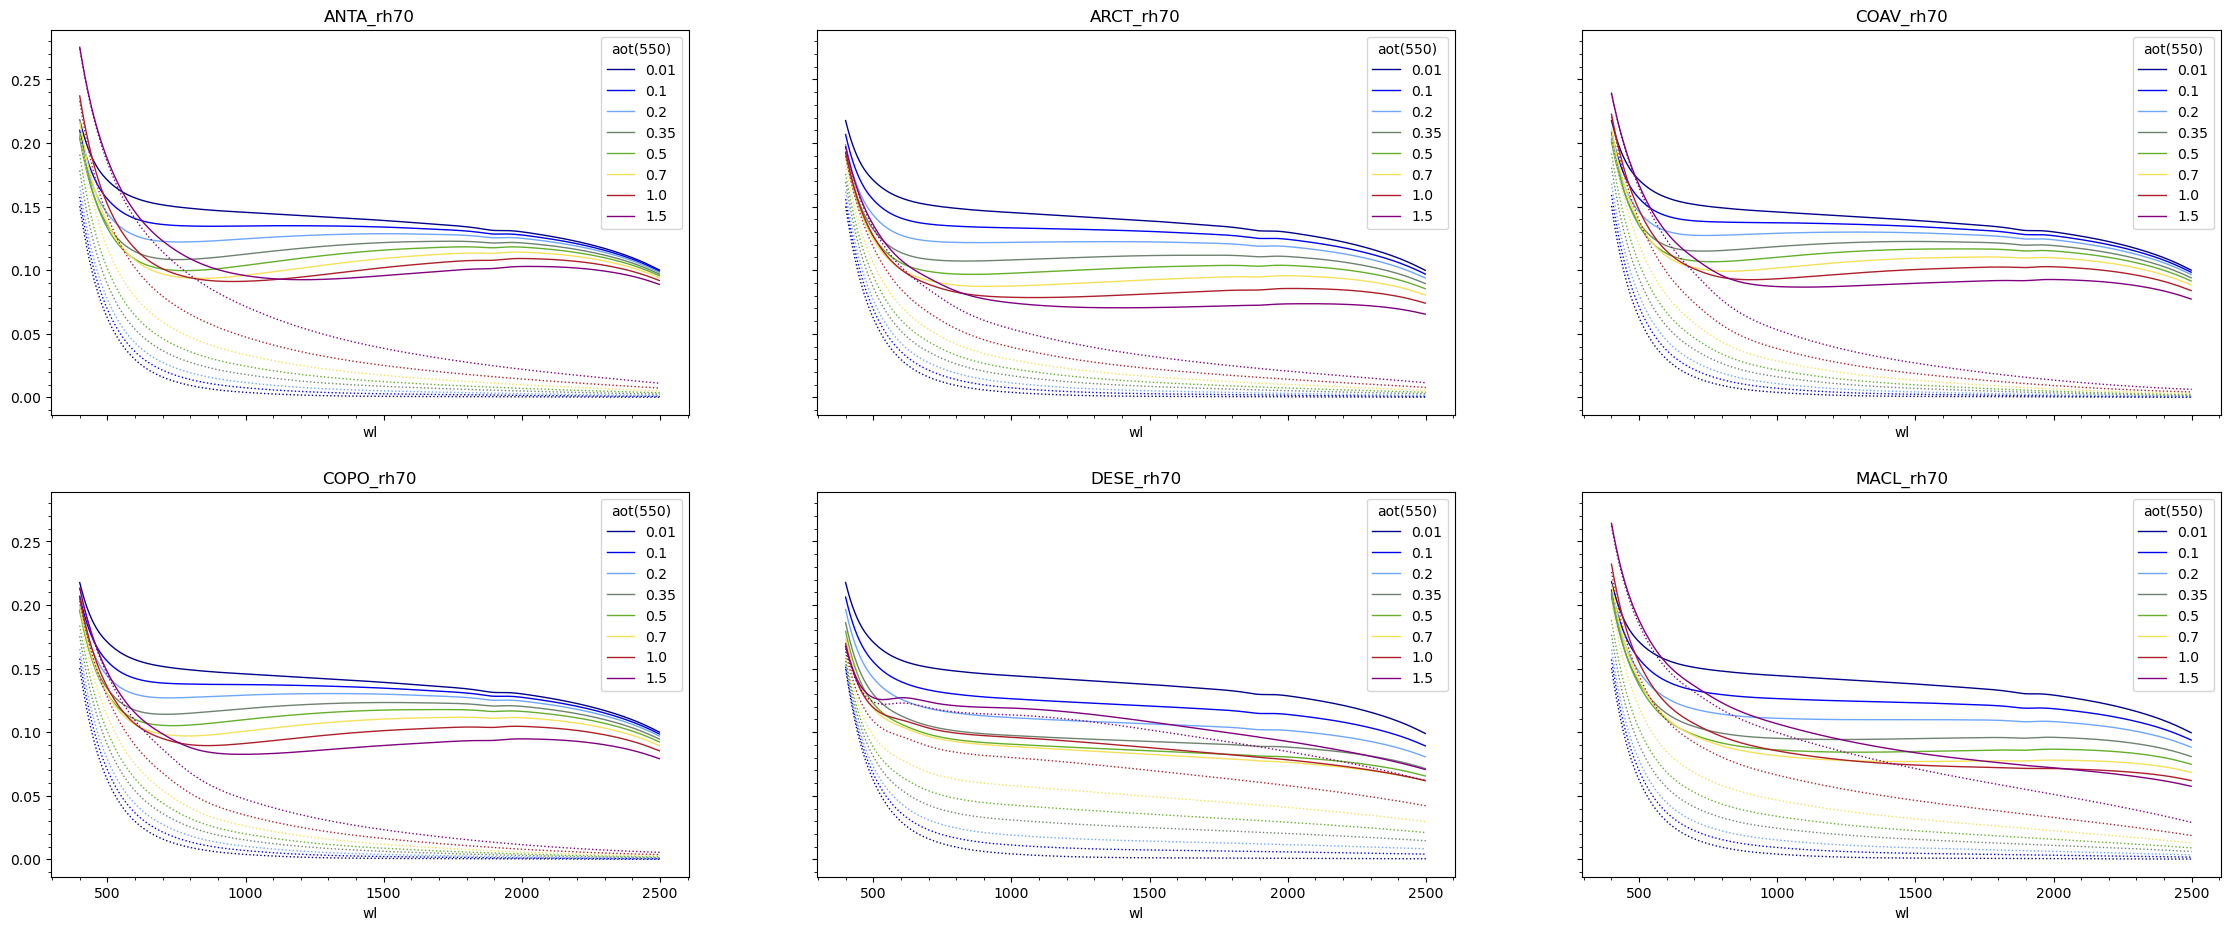

In [23]:
fig,axs = plt.subplots(2,3,figsize=(28,11),sharey=True,sharex=True)
axs=axs.ravel()
for i_,model_ in  enumerate(models):
    model=model_+rh
    

    Rtoa_lut = aero_lut.I.sel(model=model).sel(sza=sza,vza=vza,azi=azi,method='nearest').squeeze()/np.cos(np.radians(sza))
  
    Rtoa_lut=Rtoa_lut.interp(wl=wl,method='cubic')
    
    aot=aero_lut.sel(model=model).aot.interp(wl=wl,method='cubic')
    Tdir = transmittance_dir(aot,M,rot=rot)
    sunglint_corr = Tdir * sunglint_eps
    sunglint_toa=sunglint_corr *brdfg_ref#( pixel.sel(wl=slice(2150,2350))-Rtoa_lut.sel(wl=slice(2150,2350))).mean(dim='wl')
    #sunglint_toa.Rtoa.plot(x='wl',hue='aot_ref',ax=axs[0])
    
    Rsim = ( sunglint_toa+Rtoa_lut)
    for aot_ref in Rtoa_lut.aot_ref.values[1:]:
        Rtoa_lut.sel(aot_ref=aot_ref).plot(x='wl',color=cmap(norm(aot_ref)),ls=':',lw=1,ax=axs[i_])
        Rsim.sel(aot_ref=aot_ref).plot(x='wl',color=cmap(norm(aot_ref)),label=str(aot_ref),lw=1,ax=axs[i_])
    #Rtoa_sim= Rsim.interp(aot_ref=0.4)
    #Rtoa_sim.plot(x='wl',color='black',ls='--',ax=axs[i_])
    axs[i_].set_title(model)
    axs[i_].minorticks_on()
    axs[i_].legend(title='aot(550)')
    

## Transmittance of the downward irradiance

In [148]:
Ttot_Ed = aero_lut.Ed.sel(z=0)/aero_lut.Ed.isel(z=-1)

In [145]:
Ttot_Ed.name='Ttot_Ed'
Ttot_Ed.attrs['description']='Total transmittance of the downward irradiance'
#Ttot_Ed.to_netcdf('/DATA/git/satellite_app/hgrs/data/lut/transmittance_downward_irradiance.nc')

In [146]:
Ttot_Ed

<xarray.DataArray 'Ttot_Ed' (model: 8, aot_ref: 9, wl: 10, sza: 9)>
array([[[[0.7691716 , 0.7663937 , 0.75777894, ..., 0.6318432 ,
          0.5528891 , 0.42872596],
         [0.8540151 , 0.8520681 , 0.84602   , ..., 0.7515756 ,
          0.6853071 , 0.54761934],
         [0.9359    , 0.9349733 , 0.9320677 , ..., 0.8843808 ,
          0.84988487, 0.7560401 ],
         ...,
         [0.9992888 , 0.99927765, 0.99924237, ..., 0.99863   ,
          0.9982743 , 0.9975825 ],
         [0.9997821 , 0.99977857, 0.9997678 , ..., 0.9995754 ,
          0.99945617, 0.99921054],
         [0.9998915 , 0.99988973, 0.9998845 , ..., 0.999794  ,
          0.99974304, 0.99965733]],

        [[0.7663963 , 0.76357895, 0.75484633, ..., 0.6273432 ,
          0.54780555, 0.42459422],
         [0.8515014 , 0.8495171 , 0.8433239 , ..., 0.7466124 ,
          0.6786972 , 0.54001516],
         [0.9338983 , 0.9329247 , 0.9298892 , ..., 0.8796334 ,
          0.84263706, 0.74302185],
...
         [0.9790059 , 0.97832036, 0.97608656, ..., 0.9241132 ,
          0.87327176, 0.73676896],
         [0.9864019 , 0.9860115 , 0.98474264, ..., 0.9556734 ,
          0.92822003, 0.84611243],
         [0.9880114 , 0.98770785, 0.9867248 , ..., 0.964615  ,
          0.9440547 , 0.8827624 ]],

        [[0.6626669 , 0.65832275, 0.6449555 , ..., 0.4763646 ,
          0.40260616, 0.32203507],
         [0.7427768 , 0.73861307, 0.7256726 , ..., 0.54725   ,
          0.46169394, 0.36621818],
         [0.831108  , 0.8274368 , 0.8158718 , ..., 0.6350388 ,
          0.5354121 , 0.41776863],
         ...,
         [0.9682475 , 0.96721417, 0.9638601 , ..., 0.8891902 ,
          0.8193761 , 0.65750235],
         [0.9795564 , 0.9789707 , 0.97707134, ..., 0.9344788 ,
          0.8941592 , 0.78080976],
         [0.982006  , 0.98155105, 0.98007965, ..., 0.9474718 ,
          0.9168651 , 0.8282476 ]]]], dtype=float32)
Coordinates:
  * wl       (wl) float32 350.0 400.0 500.0 600.0 ... 1.6e+03 2.2e+03 2.5e+03
  * aot_ref  (aot_ref) float32 0.001 0.01 0.1 0.2 0.35 0.5 0.7 1.0 1.5
  * sza      (sza) float32 0.0 10.0 20.0 30.0 40.0 50.0 60.0 70.0 80.0
  * model    (model) object 'COAV_rh70' 'DESE_rh70' ... 'ARCT_rh70' 'ANTA_rh70'
Attributes:
    description:  Total transmittance of the downward irradiance

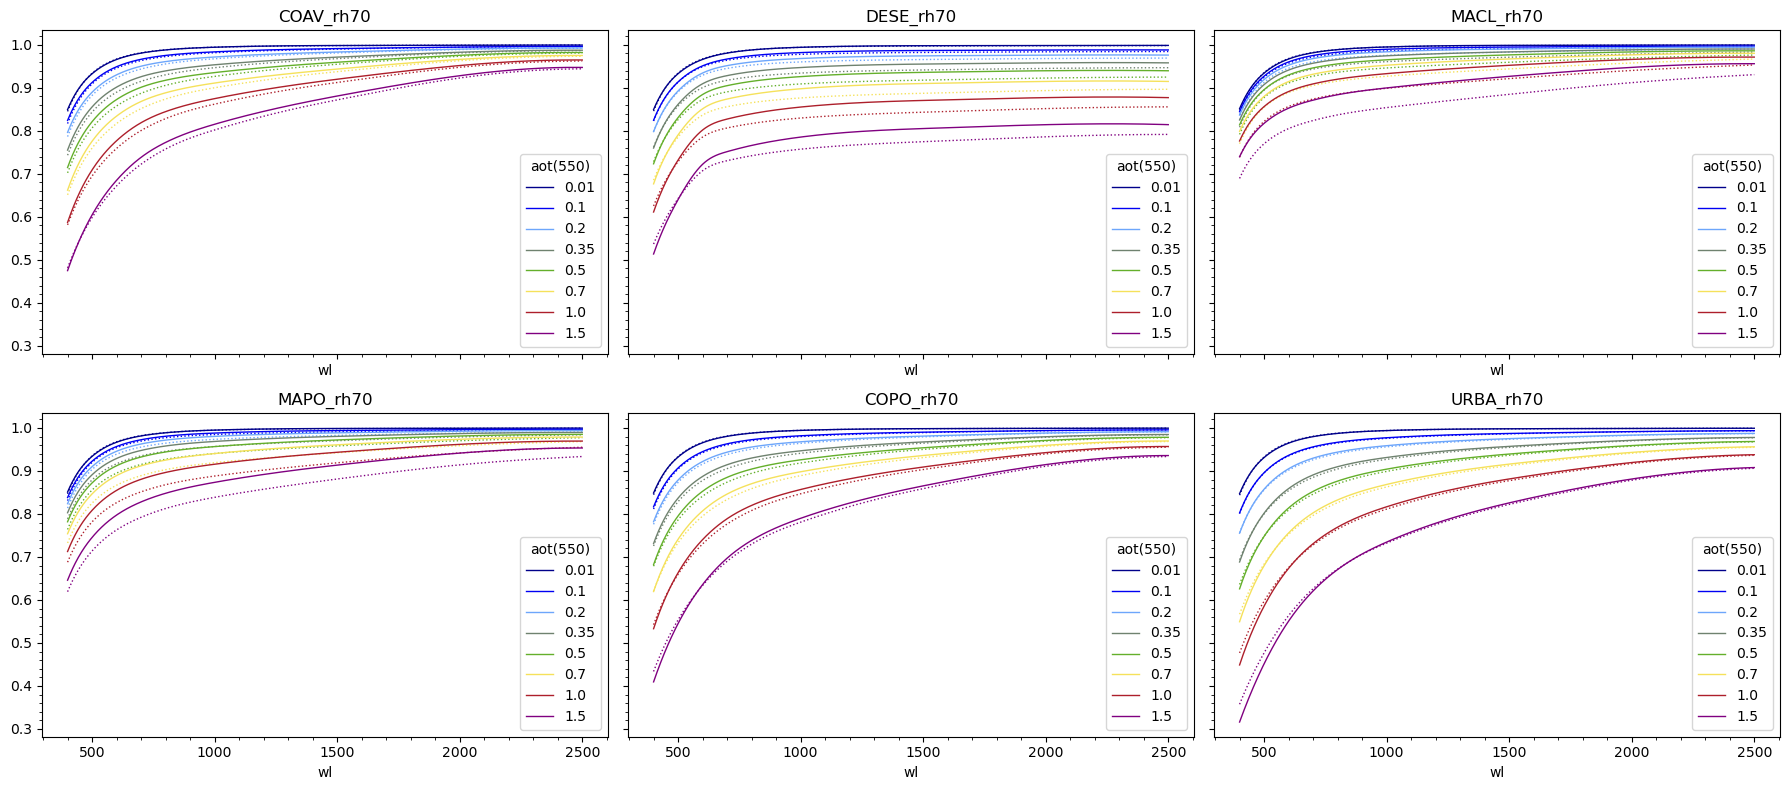

In [107]:


sza = 10
M = 1/np.cos(np.radians(sza))
fig, axs = plt.subplots(2, 3, figsize=(18, 8), sharey=True, sharex=True)
axs = axs.ravel()
for i_, model_ in enumerate(models):
    model = model_ + rh

    Ttot = Ttot_Ed.sel(model=model, sza=sza).interp(wl=wl, method='cubic')

    aot = aero_lut.sel(model=model).aot.interp(wl=wl, method='cubic')
    ssa = aero_lut.sel(model=model).ssa.interp(wl=wl, method='cubic')
    asym = aero_lut.sel(model=model).asym_factor.interp(wl=wl, method='cubic')
    # eq.12b, Tanre et al., 1979 (I do not realy understand the formulation) 
    Tsim = transmittance_dir(aot, M, rot=rot)*(np.exp((0.5*rot+0.5*(1+asym)*ssa*aot)*M)-1)#+ 0.5*transmittance_dir(ssa*aot*(1-asym), M, rot=0.52*rot)#(1-ssa)*aot+
    # personal try:
    Tsim =transmittance_dir(0.5*(1-asym)*ssa*aot+(1-ssa)*aot,M,rot=0.45*rot)
    # eq. 7, Deschamps et al., 1983
    #Tsim = (1+(0.5*rot+0.5*(1-asym)*ssa*aot+(1-ssa)*aot)*M)**-1
    for aot_ref in aero_lut.aot_ref.values[1:]:
        Ttot.sel(aot_ref=aot_ref).plot(x='wl', color=cmap(norm(aot_ref)),label=str(aot_ref),  lw=1, ax=axs[i_])
        Tsim.sel(aot_ref=aot_ref).plot(x='wl', color=cmap(norm(aot_ref)), ls=':', lw=1, ax=axs[i_])
    # Rtoa_sim= Rsim.interp(aot_ref=0.4)
    # Rtoa_sim.plot(x='wl',color='black',ls='--',ax=axs[i_])
    axs[i_].set_title(model)
    axs[i_].minorticks_on()
    axs[i_].legend(title='aot(550)')
plt.tight_layout()

## The socalled "diffuse transmittance" of the downward irradiance

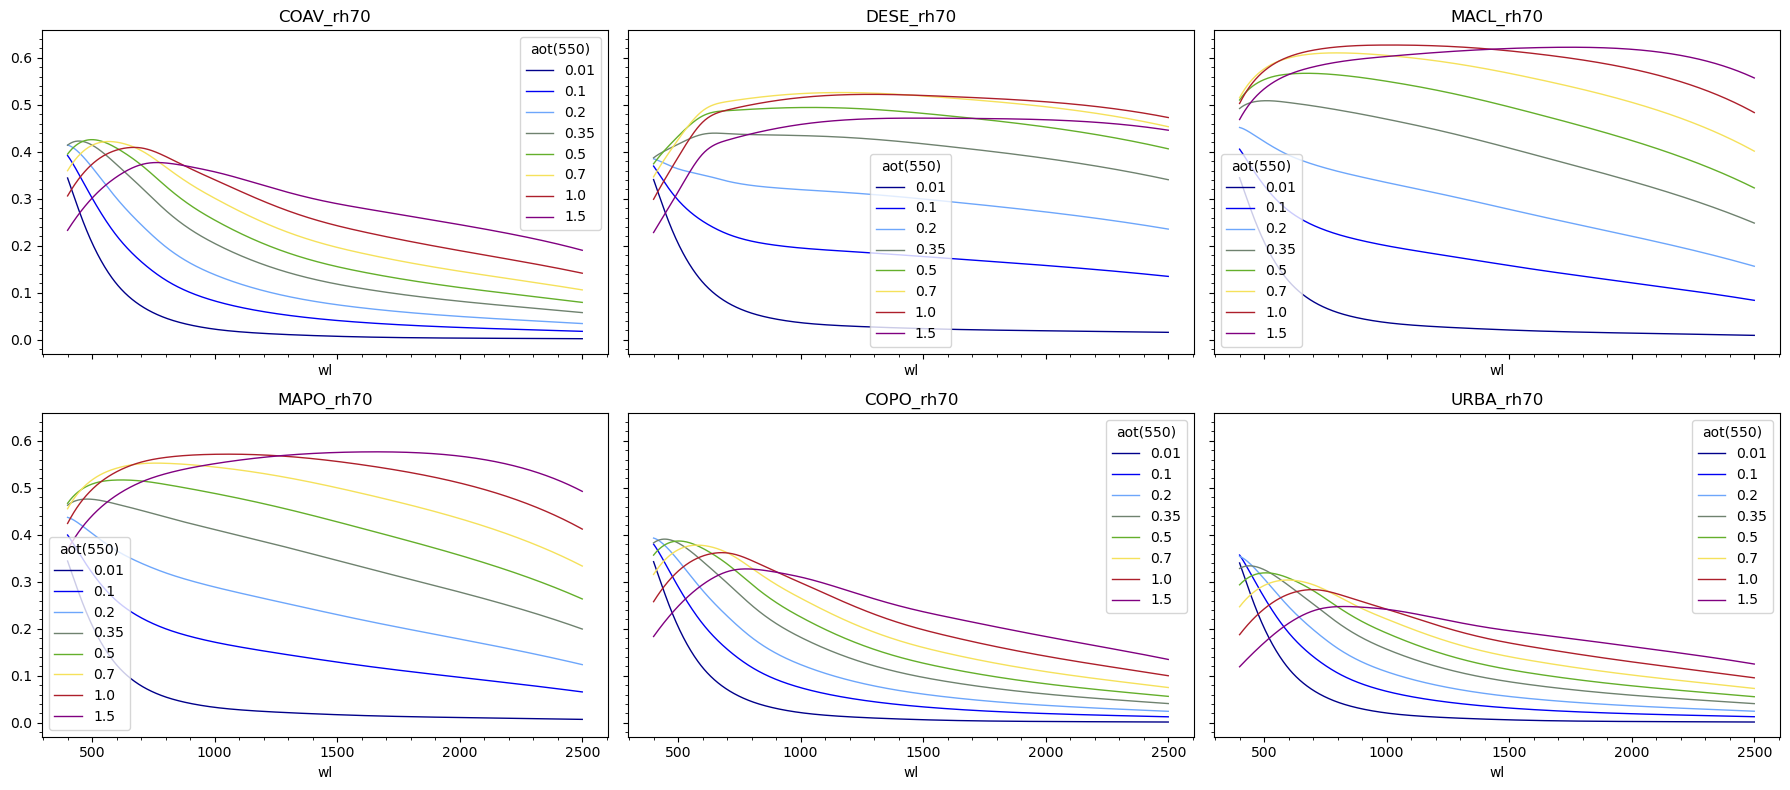

In [112]:


sza = 70
M = 1/np.cos(np.radians(sza))
fig, axs = plt.subplots(2, 3, figsize=(18, 8), sharey=True, sharex=True)
axs = axs.ravel()
for i_, model_ in enumerate(models):
    model = model_ + rh

    Ttot = Ttot_Ed.sel(model=model, sza=sza).interp(wl=wl, method='cubic')

    aot = aero_lut.sel(model=model).aot.interp(wl=wl, method='cubic')
    ssa = aero_lut.sel(model=model).ssa.interp(wl=wl, method='cubic')
    asym = aero_lut.sel(model=model).asym_factor.interp(wl=wl, method='cubic')
    
    Tdir =transmittance_dir(aot, M, rot=rot)#+ 0.5*transmittance_dir(ssa*aot*(1-asym), M, rot=0.52*rot)#(1-ssa)*aot+

    for aot_ref in aero_lut.aot_ref.values[1:]:
        (Ttot -Tdir).sel(aot_ref=aot_ref).plot(x='wl', color=cmap(norm(aot_ref)),label=str(aot_ref),  lw=1, ax=axs[i_])
        #Tdir.sel(aot_ref=aot_ref).plot(x='wl', color=cmap(norm(aot_ref)), ls=':', lw=1, ax=axs[i_])
    # Rtoa_sim= Rsim.interp(aot_ref=0.4)
    # Rtoa_sim.plot(x='wl',color='black',ls='--',ax=axs[i_])
    axs[i_].set_title(model)
    axs[i_].minorticks_on()
    axs[i_].legend(title='aot(550)')
plt.tight_layout()

## Transmittance of the upward "water" radiance

In [115]:
aero_lut = aero_lut.sel(model=aero_lut_bot.model.values)
Iw = aero_lut_bot.I - aero_lut.I
Iw

<xarray.DataArray 'I' (model: 8, wl: 10, aot_ref: 9, z: 2, sza: 9, vza: 61,
                       azi: 73)>
array([[[[[[[1.11645079e+00, 1.11645079e+00, 1.11645079e+00, ...,
             1.11645079e+00, 1.11645079e+00, 1.11645079e+00],
            [1.11647081e+00, 1.11647081e+00, 1.11647081e+00, ...,
             1.11647081e+00, 1.11647081e+00, 1.11647081e+00],
            [1.11645067e+00, 1.11645067e+00, 1.11645067e+00, ...,
             1.11645067e+00, 1.11645067e+00, 1.11645067e+00],
            ...,
            [1.01300395e+00, 1.01300395e+00, 1.01300395e+00, ...,
             1.01300395e+00, 1.01300395e+00, 1.01300395e+00],
            [1.24116504e+00, 1.24116504e+00, 1.24116504e+00, ...,
             1.24116504e+00, 1.24116504e+00, 1.24116504e+00],
            [2.60494184e+00, 2.60494184e+00, 2.60494184e+00, ...,
             2.60494184e+00, 2.60494184e+00, 2.60494184e+00]],

           [[1.09531200e+00, 1.09531200e+00, 1.09531200e+00, ...,
             1.09531200e+00, 1.09531200e+00, 1.09531200e+00],
            [1.09533727e+00, 1.09533739e+00, 1.09533751e+00, ...,
             1.09533751e+00, 1.09533739e+00, 1.09533727e+00],
            [1.09532785e+00, 1.09531796e+00, 1.09531844e+00, ...,
             1.09531844e+00, 1.09531796e+00, 1.09532785e+00],
...
             1.47210002e-01, 1.47210002e-01, 1.47210002e-01],
            [1.32089972e-01, 1.32089972e-01, 1.32090092e-01, ...,
             1.32090092e-01, 1.32089972e-01, 1.32089972e-01],
            [1.13420010e-01, 1.13430023e-01, 1.13420010e-01, ...,
             1.13420010e-01, 1.13430023e-01, 1.13420010e-01]],

           [[1.15688063e-01, 1.15688063e-01, 1.15688063e-01, ...,
             1.15688063e-01, 1.15688063e-01, 1.15688063e-01],
            [1.15938440e-01, 1.15938231e-01, 1.15938574e-01, ...,
             1.15938574e-01, 1.15938231e-01, 1.15938440e-01],
            [1.15859725e-01, 1.15859702e-01, 1.15859568e-01, ...,
             1.15859568e-01, 1.15859702e-01, 1.15859725e-01],
            ...,
            [5.89599609e-02, 5.89599609e-02, 5.89600801e-02, ...,
             5.89600801e-02, 5.89599609e-02, 5.89599609e-02],
            [5.28998375e-02, 5.29000759e-02, 5.28999567e-02, ...,
             5.28999567e-02, 5.29000759e-02, 5.28998375e-02],
            [4.54299450e-02, 4.54301834e-02, 4.54299450e-02, ...,
             4.54299450e-02, 4.54301834e-02, 4.54299450e-02]]]]]]],
      dtype=float32)
Coordinates:
  * wl       (wl) float32 350.0 400.0 500.0 600.0 ... 1.6e+03 2.2e+03 2.5e+03
  * aot_ref  (aot_ref) float32 0.001 0.01 0.1 0.2 0.35 0.5 0.7 1.0 1.5
  * z        (z) float32 0.0 3e+05
  * sza      (sza) float32 0.0 10.0 20.0 30.0 40.0 50.0 60.0 70.0 80.0
  * vza      (vza) float32 0.0 1.14 2.62 4.11 5.61 ... 84.77 86.27 87.76 89.25
  * azi      (azi) float32 0.0 5.0 10.0 15.0 20.0 ... 345.0 350.0 355.0 360.0
  * model    (model) object 'COAV_rh70' 'DESE_rh70' ... 'ARCT_rh70' 'ANTA_rh70'

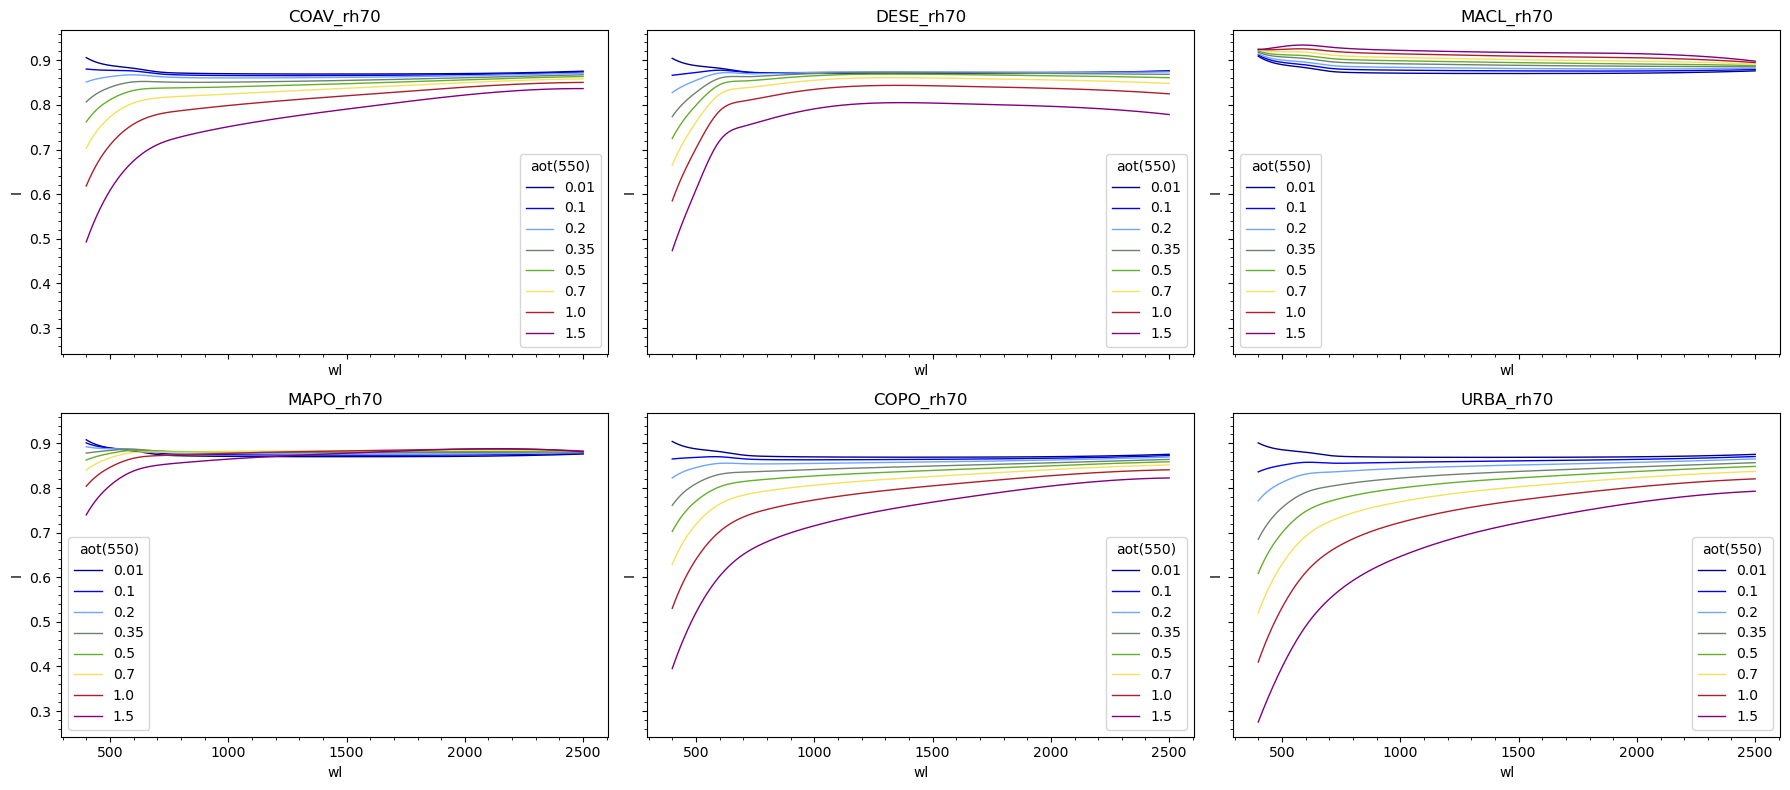

In [134]:
isza = 3
ivza=3
iazi=10
fig, axs = plt.subplots(2, 3, figsize=(18, 8), sharey=True, sharex=True)
axs = axs.ravel()
for i_, model_ in enumerate(models):
    model = model_ + rh

    Iw_=Iw.sel(model=model).isel(vza=ivza, sza=isza, azi=iazi).interp(wl=wl, method='cubic').isel(z=-2)
    for aot_ref in aero_lut.aot_ref.values[1:]:
        Iw_.sel(aot_ref=aot_ref).plot(x='wl', color=cmap(norm(aot_ref)),label=str(aot_ref),  lw=1, ax=axs[i_])
       
    # Rtoa_sim= Rsim.interp(aot_ref=0.4)
    # Rtoa_sim.plot(x='wl',color='black',ls='--',ax=axs[i_])
    axs[i_].set_title(model)
    axs[i_].minorticks_on()
    axs[i_].legend(title='aot(550)')
plt.tight_layout()

In [118]:
Ttot_Lu = Iw.isel(z=-1) / Iw.sel(z=0)

In [141]:
Ttot_Lu.name='Ttot_Lu'
Ttot_Lu.attrs['description']='Total transmittance of the upward "water" radiance'
#Ttot_Lu.to_netcdf('/DATA/git/satellite_app/hgrs/data/lut/transmittance_upward_radiance.nc')

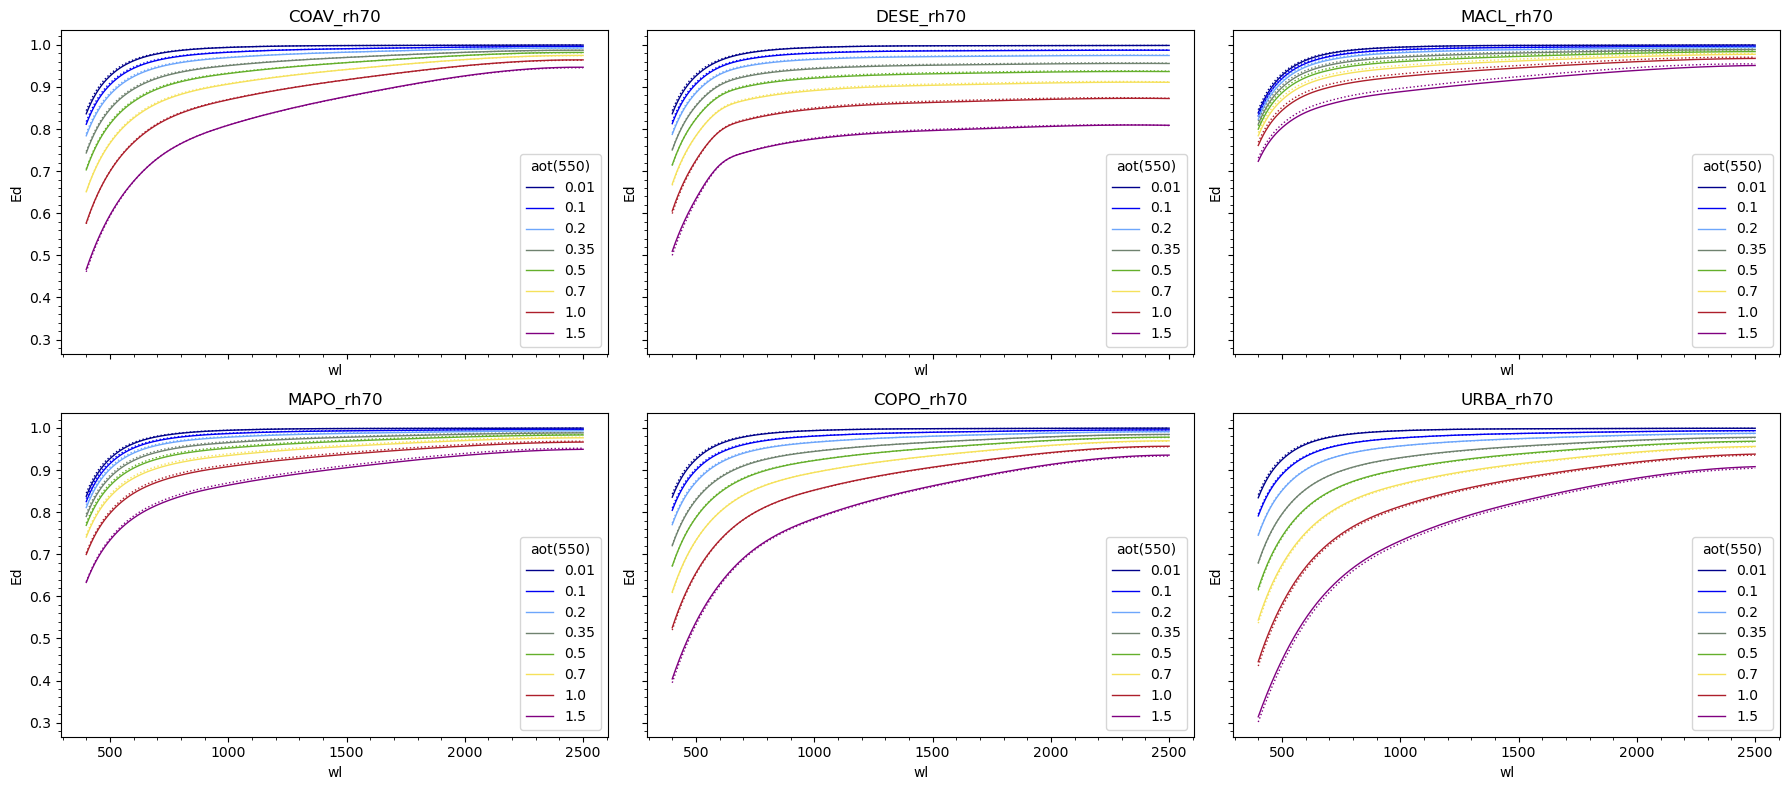

In [163]:
sza = 60

isza = 7
ivza=3
iazi=10
M = np.cos(np.radians(szas[isza]))
fig, axs = plt.subplots(2, 3, figsize=(18, 8), sharey=True, sharex=True)
axs = axs.ravel()
for i_, model_ in enumerate(models):
    model = model_ + rh

    Ttot = Ttot_Lu.sel(model=model).isel(vza=ivza, sza=isza, azi=iazi).interp(wl=wl, method='cubic')
    vza=Ttot.vza.values
    Ttot_Ed_ = Ttot_Ed.sel(model=model).interp(sza=vza).interp(wl=wl, method='cubic')**1.05
    
    aot = aero_lut.sel(model=model).aot.interp(wl=wl, method='cubic')
    ssa = aero_lut.sel(model=model).ssa.interp(wl=wl, method='cubic')
    asym = aero_lut.sel(model=model).asym_factor.interp(wl=wl, method='cubic')
    
    Tsim = transmittance_dir((1-ssa)*aot+ssa*aot*(1-asym), M, rot=0.52*rot)#(1-ssa)*aot+
 # eq.12b, Tanre et al., 1979 (I do not realy understand the formulation) 
    Tsim = transmittance_dir(aot, M, rot=rot)*(np.exp((0.5*rot+0.5*(1+asym)*ssa*aot)*M)-1)#+ 0.5*transmittance_dir(ssa*aot*(1-asym), M, rot=0.52*rot)#(1-ssa)*aot+
    # personal try:
    Tsim =transmittance_dir(0.5*(1-asym)*ssa*aot+(1-ssa)*aot,M,rot=rot)
    # eq. 7, Deschamps et al., 1983
    Tsim = (1+(0.5*rot+0.5*(1-asym)*ssa*aot+(1-ssa)*aot)*M)**-1
    for aot_ref in aero_lut.aot_ref.values[1:]:
        Ttot.sel(aot_ref=aot_ref).plot(x='wl', color=cmap(norm(aot_ref)),label=str(aot_ref),  lw=1, ax=axs[i_])
        Ttot_Ed_.sel(aot_ref=aot_ref).plot(x='wl', color=cmap(norm(aot_ref)), ls=':', lw=1, ax=axs[i_])
    # Rtoa_sim= Rsim.interp(aot_ref=0.4)
    # Rtoa_sim.plot(x='wl',color='black',ls='--',ax=axs[i_])
    axs[i_].set_title(model)
    axs[i_].minorticks_on()
    axs[i_].legend(title='aot(550)')
plt.tight_layout()

## Total up and downward transmitance

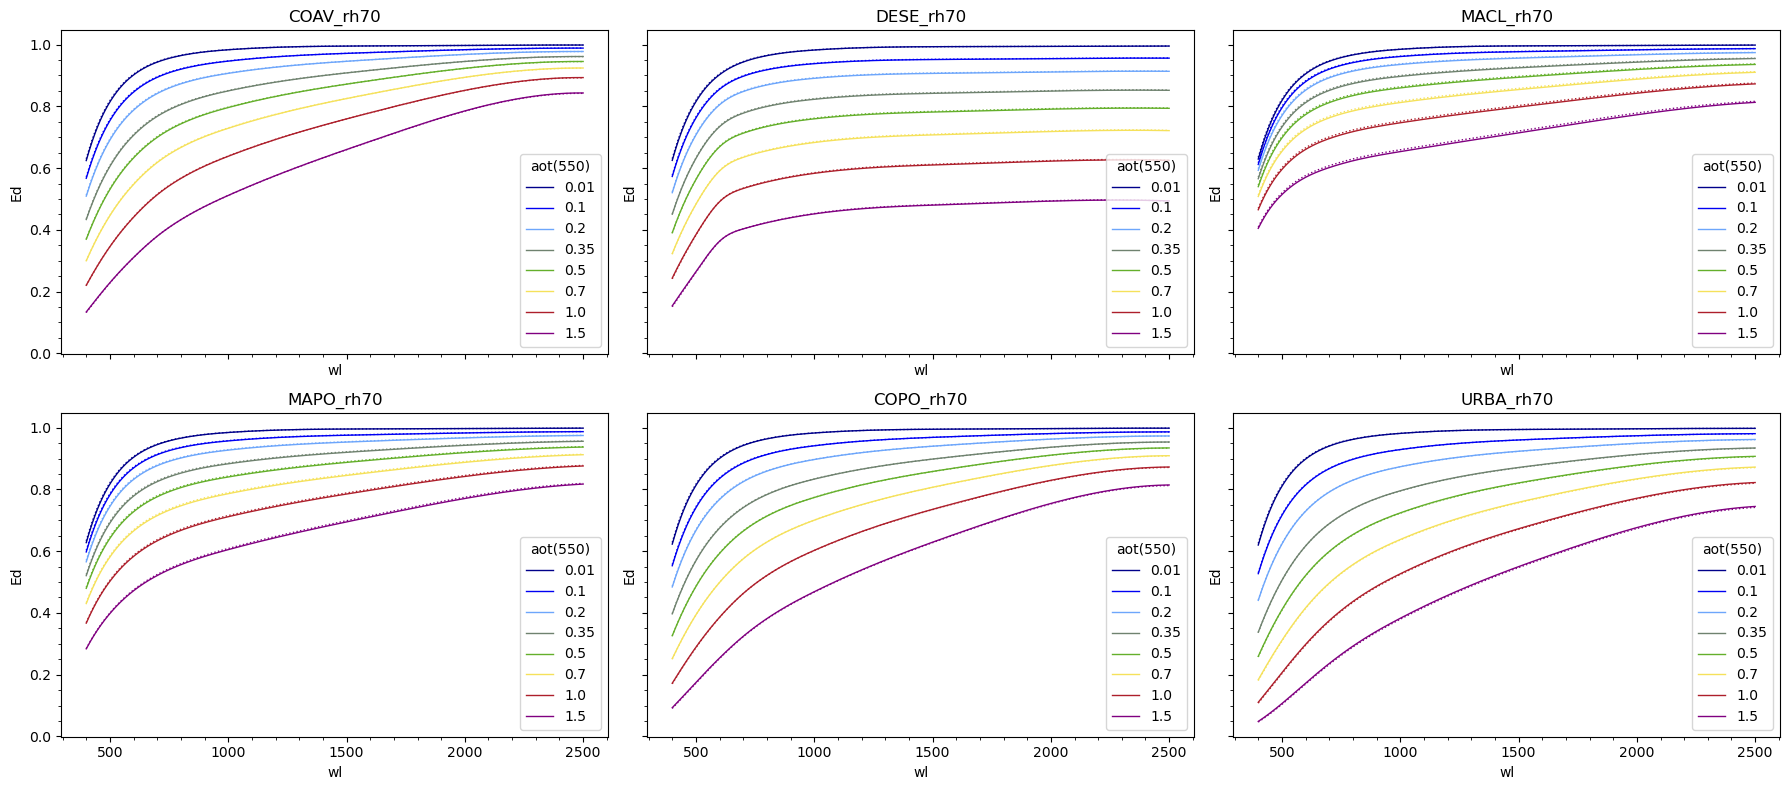

In [164]:

isza = 7
ivza=3
iazi=10
M = np.cos(np.radians(szas[isza]))
fig, axs = plt.subplots(2, 3, figsize=(18, 8), sharey=True, sharex=True)
axs = axs.ravel()
for i_, model_ in enumerate(models):
    model = model_ + rh
    Ttot_Ed_ = Ttot_Ed.sel(model=model, sza=sza).interp(wl=wl, method='cubic')
    Ttot_Lu_ = Ttot_Lu.sel(model=model).isel(vza=ivza, sza=isza, azi=iazi).interp(wl=wl, method='cubic')
    vza=Ttot.vza.values
    Ttot_Lu_sim = Ttot_Ed.sel(model=model).interp(sza=vza).interp(wl=wl, method='cubic')**1.05
    Ttot = Ttot_Ed_ *Ttot_Lu_
    Ttot_sim = Ttot_Ed_ *Ttot_Lu_sim
    aot = aero_lut.sel(model=model).aot.interp(wl=wl, method='cubic')
    ssa = aero_lut.sel(model=model).ssa.interp(wl=wl, method='cubic')
    asym = aero_lut.sel(model=model).asym_factor.interp(wl=wl, method='cubic')
    
    Tsim = transmittance_dir((1-ssa)*aot+ssa*aot*(1-asym), M, rot=0.52*rot)#(1-ssa)*aot+
 # eq.12b, Tanre et al., 1979 (I do not realy understand the formulation) 
    Tsim = transmittance_dir(aot, M, rot=rot)*(np.exp((0.5*rot+0.5*(1+asym)*ssa*aot)*M)-1)#+ 0.5*transmittance_dir(ssa*aot*(1-asym), M, rot=0.52*rot)#(1-ssa)*aot+
    # personal try:
    Tsim =transmittance_dir(0.5*(1-asym)*ssa*aot+(1-ssa)*aot,M,rot=rot)
    # eq. 7, Deschamps et al., 1983
    Tsim = (1+(0.5*rot+0.5*(1-asym)*ssa*aot+(1-ssa)*aot)*M)**-1
    for aot_ref in aero_lut.aot_ref.values[1:]:
        Ttot.sel(aot_ref=aot_ref).plot(x='wl', color=cmap(norm(aot_ref)),label=str(aot_ref),  lw=1, ax=axs[i_])
        Ttot_sim.sel(aot_ref=aot_ref).plot(x='wl', color=cmap(norm(aot_ref)), ls=':', lw=1, ax=axs[i_])
    # Rtoa_sim= Rsim.interp(aot_ref=0.4)
    # Rtoa_sim.plot(x='wl',color='black',ls='--',ax=axs[i_])
    axs[i_].set_title(model)
    axs[i_].minorticks_on()
    axs[i_].legend(title='aot(550)')
plt.tight_layout()

In [63]:
aero_lut['I'].isel(z=-2)

<xarray.DataArray 'I' (model: 32, wl: 10, aot_ref: 9, sza: 9, vza: 61, azi: 73)>
[115421760 values with dtype=float32]
Coordinates:
  * wl       (wl) float32 350.0 400.0 500.0 600.0 ... 1.6e+03 2.2e+03 2.5e+03
  * aot_ref  (aot_ref) float32 0.001 0.01 0.1 0.2 0.35 0.5 0.7 1.0 1.5
    z        float32 0.0
  * sza      (sza) float32 0.0 10.0 20.0 30.0 40.0 50.0 60.0 70.0 80.0
  * vza      (vza) float32 0.0 1.14 2.62 4.11 5.61 ... 84.77 86.27 87.76 89.25
  * azi      (azi) float32 0.0 5.0 10.0 15.0 20.0 ... 345.0 350.0 355.0 360.0
  * model    (model) object 'COAV_rh0' 'DESE_rh0' ... 'ARCT_rh99' 'ANTA_rh99'
Attributes:
    unit:         -
    long_name:    normalized_radiance
    description:  I stokes parameter, can be scaled into radiance unit by mul...

In [58]:
Trans = aero_lut['I'].isel(z=-1) / aero_lut['I'].isel(z=-2)
ivza = 8
szas = Trans.sza.values
vzas = Trans.vza.values

muv = np.cos(np.radians(Trans.vza))

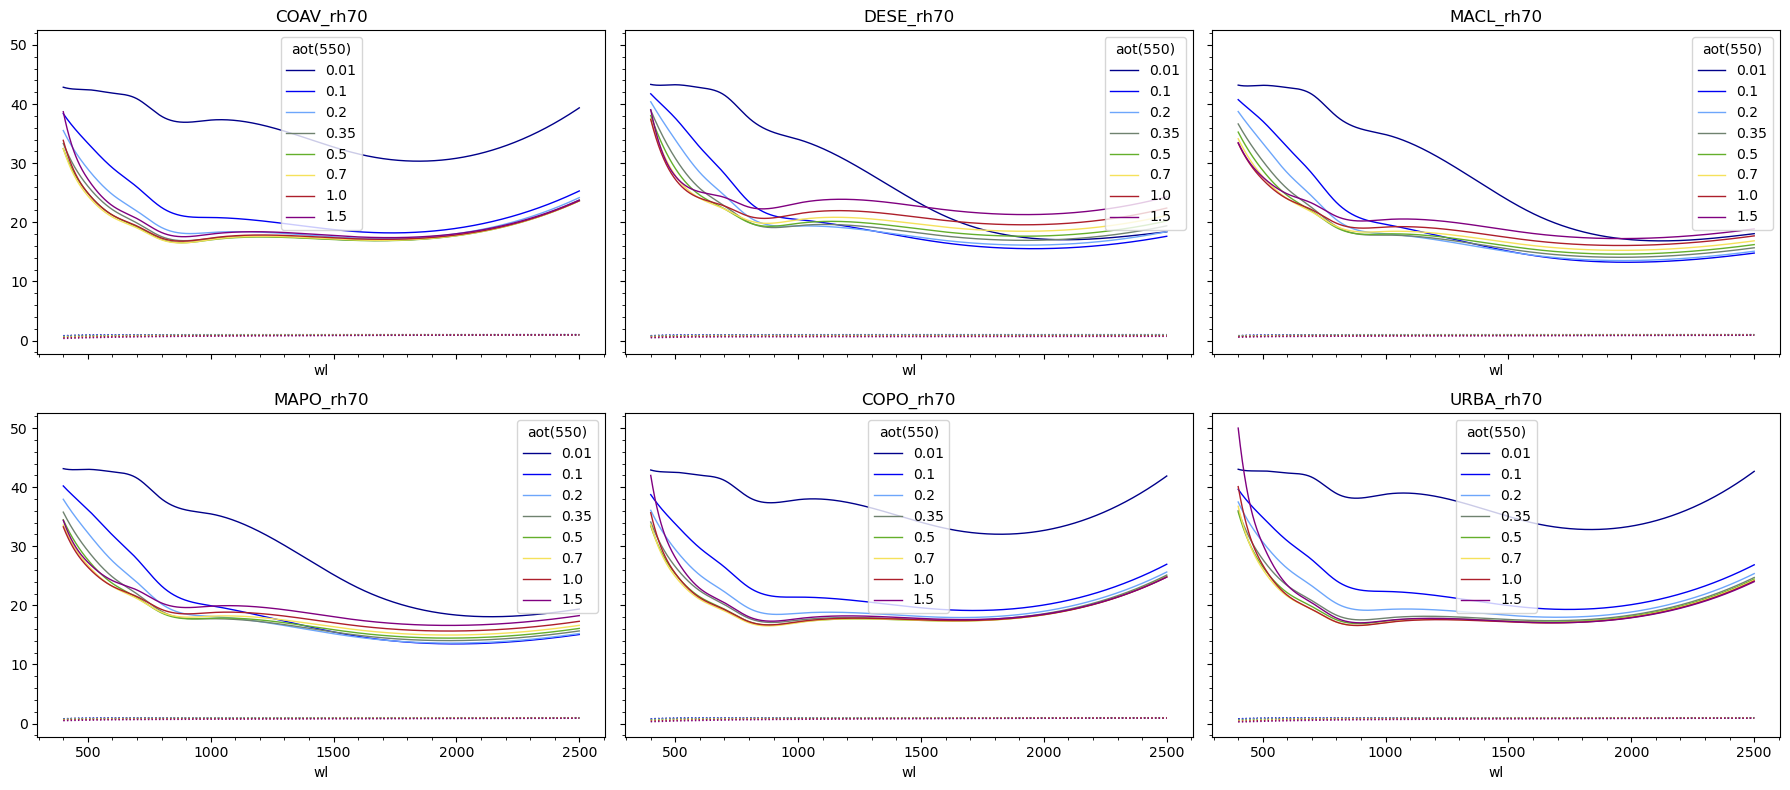

In [61]:
# ---------------------------------------
# transmittance of upward radiance
# ---------------------------------------

isza = 6
ivza=3
iazi=10
M = np.cos(np.radians(sza))
fig, axs = plt.subplots(2, 3, figsize=(18, 8), sharey=True, sharex=True)
axs = axs.ravel()
for i_, model_ in enumerate(models):
    model = model_ + rh

    T_Lu = Trans.sel(model=model).isel(vza=ivza, sza=isza, azi=iazi).interp(wl=wl, method='cubic')
    vza=T_Lu.vza.values
    M = np.cos(np.radians(vza))
    aot = aero_lut.sel(model=model).aot.interp(wl=wl, method='cubic')
    ssa = aero_lut.sel(model=model).ssa.interp(wl=wl, method='cubic')
    asym = aero_lut.sel(model=model).asym_factor.interp(wl=wl, method='cubic')
    
    Tsim = transmittance_dir((1-ssa)*aot+ssa*aot*(1-asym), M, rot=0.52*rot)#(1-ssa)*aot+

    for aot_ref in aero_lut.aot_ref.values[1:]:
        T_Lu.sel(aot_ref=aot_ref).plot(x='wl', color=cmap(norm(aot_ref)),label=str(aot_ref),  lw=1, ax=axs[i_])
        Tsim.sel(aot_ref=aot_ref).plot(x='wl', color=cmap(norm(aot_ref)), ls=':', lw=1, ax=axs[i_])
    # Rtoa_sim= Rsim.interp(aot_ref=0.4)
    # Rtoa_sim.plot(x='wl',color='black',ls='--',ax=axs[i_])
    axs[i_].set_title(model)
    axs[i_].minorticks_on()
    axs[i_].legend(title='aot(550)')
plt.tight_layout()



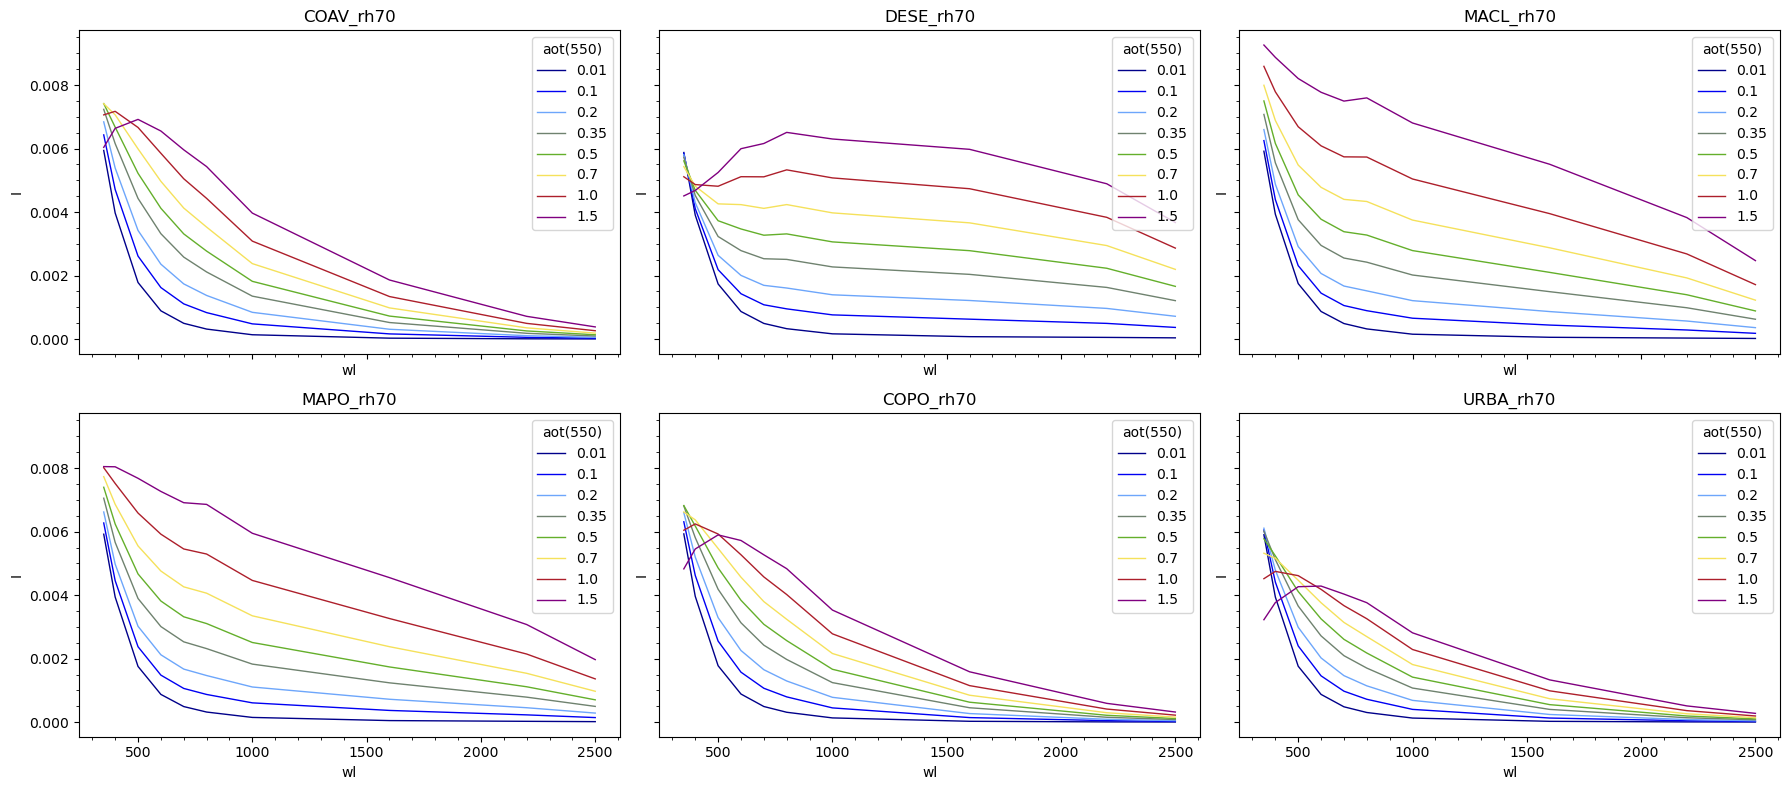

In [69]:

isza = 6
ivza=3
iazi=10
M = np.cos(np.radians(sza))
fig, axs = plt.subplots(2, 3, figsize=(18, 8), sharey=True, sharex=True)
axs = axs.ravel()
for i_, model_ in enumerate(models):
    model = model_ + rh

    Lu = aero_lut.I.sel(model=model).isel(vza=ivza, sza=isza, azi=iazi).isel(z=0)
    sza=Lu.sza.values
    Lu =(Lu/np.cos(np.radians(sza)))#.interp(wl=wl, method='cubic')
    #M = np.cos(np.radians(vza))
    #aot = aero_lut.sel(model=model).aot.interp(wl=wl, method='cubic')
    #ssa = aero_lut.sel(model=model).ssa.interp(wl=wl, method='cubic')
    #asym = aero_lut.sel(model=model).asym_factor.interp(wl=wl, method='cubic')
    
    #Tsim = transmittance_dir((1-ssa)*aot+ssa*aot*(1-asym), M, rot=0.52*rot)#(1-ssa)*aot+

    for aot_ref in aero_lut.aot_ref.values[1:]:
        Lu.sel(aot_ref=aot_ref).plot(x='wl', color=cmap(norm(aot_ref)),label=str(aot_ref),  lw=1, ax=axs[i_])
        #Tsim.sel(aot_ref=aot_ref).plot(x='wl', color=cmap(norm(aot_ref)), ls=':', lw=1, ax=axs[i_])
    # Rtoa_sim= Rsim.interp(aot_ref=0.4)
    # Rtoa_sim.plot(x='wl',color='black',ls='--',ax=axs[i_])
    axs[i_].set_title(model)
    axs[i_].minorticks_on()
    axs[i_].legend(title='aot(550)')
plt.tight_layout()



In [48]:
cams = xr.open_dataset('/DATA/projet/magellium/acix-iii/cams/PRS_L1_STD_OFFL_20220930074620_20220930074624_0001_cams.nc')

In [49]:
aod = cams[['aod355', 'aod380', 'aod400', 'aod440', 'aod469', 'aod500', 'aod550', 'aod645', 'aod670',
 'aod800', 'aod865','aod1020', 'aod1064', 'aod1240', 'aod1640', 'aod2130']].to_pandas()
aod.index=aod.index.str.replace('aod','').astype(int)
cams_aod=aod.to_xarray().rename({'index':'wl'})


In [54]:
rh='_rh70'
models = ['ANTA'+rh,'ARCT'+rh,'COAV'+rh, 'COPO'+rh, 'DESE'+rh, 'MACL'+rh, 'MAPO'+rh, 'URBA'+rh]


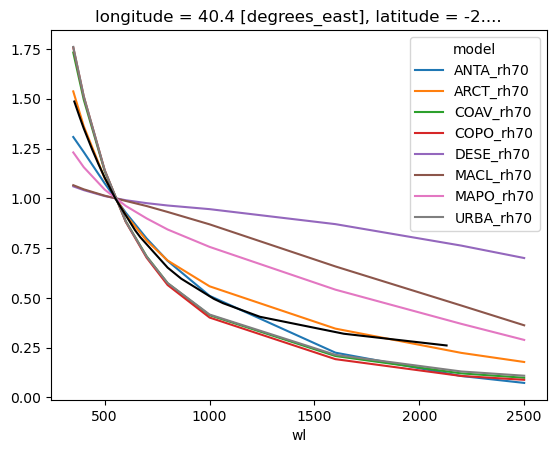

In [55]:
aero_lut.aot.sel(model=models,aot_ref=1).plot(hue='model')
(cams_aod/cams.aod550).plot(color='black')

In [1]:
lut_aod=aero_lut.aot.sel(model=models,aot_ref=1).interp(wl=cams_aod.wl)
rank = np.abs((cams_aod/cams.aod550)-lut_aod).sum('wl') 
plt.figure(figsize=(35,4))
plt.bar(x=rank.model, height=rank.values)

NameError: name 'aero_lut' is not defined

In [10]:
aero_lut

<xarray.Dataset>
Dimensions:            (wl: 10, model: 32, aot_ref: 9, z: 2, sza: 9, vza: 61,
                        azi: 73)
Coordinates:
  * wl                 (wl) float32 350.0 400.0 500.0 ... 2.2e+03 2.5e+03
  * aot_ref            (aot_ref) float32 0.001 0.01 0.1 0.2 0.35 0.5 0.7 1.0 1.5
  * z                  (z) float32 0.0 3e+05
  * sza                (sza) float32 0.0 10.0 20.0 30.0 40.0 50.0 60.0 70.0 80.0
  * vza                (vza) float32 0.0 1.14 2.62 4.11 ... 86.27 87.76 89.25
  * azi                (azi) float32 0.0 5.0 10.0 15.0 ... 350.0 355.0 360.0
  * model              (model) object 'COAV_rh0' 'DESE_rh0' ... 'ANTA_rh99'
Data variables: (12/20)
    wl_ref             (model, wl, aot_ref) float32 ...
    Cext_ref           (model, wl, aot_ref) float32 ...
    ssa_ref            (model, wl, aot_ref) float32 ...
    aot                (model, wl, aot_ref) float32 ...
    Cext               (model, wl, aot_ref) float32 ...
    ssa                (model, wl, aot_ref) float32 ...
    ...                 ...
    Eddir              (model, aot_ref, wl, z, sza) float32 ...
    Eudir              (model, aot_ref, wl, z, sza) float32 ...
    Eodir              (model, aot_ref, wl, z, sza) float32 ...
    I                  (model, wl, aot_ref, z, sza, vza, azi) float32 ...
    Q                  (model, wl, aot_ref, z, sza, vza, azi) float32 ...
    U                  (model, wl, aot_ref, z, sza, vza, azi) float32 ...

In [21]:
aot=aero_lut.sel(model=model).aot.interp(wl=wl,method='cubic')
Tdir = transmittance_dir(aot,M,rot=rot)
Tdir

<xarray.DataArray (wl: 1000, aot_ref: 9)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * wl       (wl) float64 400.0 402.1 404.2 ... 2.496e+03 2.498e+03 2.5e+03
  * aot_ref  (aot_ref) float32 0.001 0.01 0.1 0.2 0.35 0.5 0.7 1.0 1.5
    model    <U9 'URBA_rh70'

## check NDWI and similar indices

In [ ]:
fig,axs = plt.subplots(2,3,figsize=(28,11),sharey=True,sharex=True)
axs=axs.ravel()
wl=[550,865,1600,2200]
for i_,model_ in  enumerate(models):
    model=model_+rh
    

    Rtoa_lut = aero_lut.I.sel(model=model).drop_isel(aot_ref=[0,4,6,8]).sel(sza=sza,vza=vza,azi=azi,method='nearest').squeeze()/np.cos(np.radians(sza))
  
    Rtoa_lut=Rtoa_lut.interp(wl=wl,method='cubic')
    
    aot=aero_lut.sel(model=model).aot.interp(wl=wl,method='cubic')
    Tdir = transmittance_dir(aot,M,rot=rot)
    sunglint_corr = Tdir * sunglint_eps
    sunglint_toa=sunglint_corr *brdfg_ref#( pixel.sel(wl=slice(2150,2350))-Rtoa_lut.sel(wl=slice(2150,2350))).mean(dim='wl')
    #sunglint_toa.Rtoa.plot(x='wl',hue='aot_ref',ax=axs[0])
    
    Rsim = ( sunglint_toa+Rtoa_lut)
    
    
    for aot_ref in Rtoa_lut.aot_ref.values[1:]:
        Rtoa_lut.sel(aot_ref=aot_ref).plot(x='wl',color=cmap(norm(aot_ref)),ls=':',lw=1,ax=axs[i_])
        Rsim.sel(aot_ref=aot_ref).plot(x='wl',color=cmap(norm(aot_ref)),label=str(aot_ref),lw=1,ax=axs[i_])
    #Rtoa_sim= Rsim.interp(aot_ref=0.4)
    #Rtoa_sim.plot(x='wl',color='black',ls='--',ax=axs[i_])
    axs[i_].set_title(model)
    axs[i_].minorticks_on()
    axs[i_].legend(title='aot(550)')

In [29]:
Rtoa_lut = aero_lut.I.isel(sza=slice(1,9)).sel(vza=vza,azi=azi,method='nearest').squeeze()/np.cos(np.radians(sza))  
Rtoa_lut.isel(wl=2)#.interp(wl=wl,method='quadratic')

<xarray.DataArray 'I' (model: 32, aot_ref: 9, sza: 8)>
array([[[0.07594077, 0.07266093, 0.06744726, ..., 0.05016746,
         0.04546707, 0.03575967],
        [0.07734447, 0.07382196, 0.06869928, ..., 0.0509879 ,
         0.04614002, 0.03603316],
        [0.09055009, 0.08498763, 0.07841007, ..., 0.05881121,
         0.05238169, 0.03857896],
        ...,
        [0.14903834, 0.13966814, 0.12883326, ..., 0.09614938,
         0.07699592, 0.04598284],
        [0.16788973, 0.15865007, 0.14835562, ..., 0.10723046,
         0.08287992, 0.04750508],
        [0.19151108, 0.18248028, 0.17072377, ..., 0.11886634,
         0.08856745, 0.04904794]],

       [[0.07594572, 0.07262751, 0.06740706, ..., 0.05013091,
         0.04543509, 0.03574375],
        [0.0773617 , 0.0734631 , 0.06826131, ..., 0.05060908,
         0.04581   , 0.03586581],
        [0.09030925, 0.0814843 , 0.07418773, ..., 0.05521847,
         0.04937129, 0.03710438],
...
        [0.15201207, 0.13506919, 0.11951278, ..., 0.09049644,
         0.07542892, 0.04629758],
        [0.16993402, 0.15485525, 0.1413247 , ..., 0.10622582,
         0.08527325, 0.049338  ],
        [0.19761908, 0.18635081, 0.17300564, ..., 0.12953256,
         0.09885106, 0.05372769]],

       [[0.07600787, 0.07266915, 0.06743173, ..., 0.05012881,
         0.04543705, 0.03574962],
        [0.07796832, 0.07386712, 0.06850517, ..., 0.05058205,
         0.04582436, 0.0359192 ],
        [0.09606636, 0.08537325, 0.07660835, ..., 0.05513805,
         0.04962676, 0.03758959],
        ...,
        [0.168891  , 0.14306481, 0.12382989, ..., 0.0865083 ,
         0.07286366, 0.04594055],
        [0.19106854, 0.1657345 , 0.14737396, ..., 0.10211496,
         0.08301058, 0.04921125],
        [0.22350791, 0.20124158, 0.18203384, ..., 0.1268211 ,
         0.09796337, 0.05417179]]], dtype=float32)
Coordinates:
    wl       float32 500.0
  * aot_ref  (aot_ref) float32 0.001 0.01 0.1 0.2 0.35 0.5 0.7 1.0 1.5
    z        float32 3e+05
    vza      float32 10.09
    azi      float32 90.0
  * sza      (sza) float32 10.0 20.0 30.0 40.0 50.0 60.0 70.0 80.0
  * model    (model) object 'COAV_rh0' 'DESE_rh0' ... 'ARCT_rh99' 'ANTA_rh99'

In [18]:
aero_lut.I.drop_isel(aot_ref=[0,4,6,8]).sel(model=model)

SyntaxError: positional argument follows keyword argument (1658192731.py, line 1)